# 📱 Exploratory Data Analysis: Screen Time Patterns & Student Attention Spans
**Jaypee Institute of Information Technology, Noida**  
**Batch F-13 | Course: Fundamentals of Data Analytics Lab (25B16CS211)**  
**Team:** Yash Singhal · Krishna Kumar Karnani · Shakti Sidhu · Himani Kumari

---
## Part 1: Importing Libraries & Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Styling ──────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [2]:
# Load dataset
df = pd.read_csv('students_screentime.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (50000, 19)
Columns: ['Age Group', 'Gender', 'Education Level', 'Occupation', 'Average Screen Time', 'Device', 'Screen Activity', 'App Category', 'Screen Time Period', 'Environment', 'Productivity', 'Attention Span', 'Work Strategy', 'Notification Handling', 'Usage of Productivity Apps', 'App_Category', 'Att_Score', 'Screen_Hours', 'Prod_Score']


,Age Group,Gender,Education Level,Occupation,Average Screen Time,Device,Screen Activity,App Category,Screen Time Period,Environment,Productivity,Attention Span,Work Strategy,Notification Handling,Usage of Productivity Apps,App_Category,Att_Score,Screen_Hours,Prod_Score
0,25–34,Female,Undergraduate,Professional,4–6,Smartphone,Academic/Work-related,"Social Media (e.g., Facebook, Instagram, Linke...",Evening (6 PM–10 PM),Quite workplace,"Extremely productive, i efficiently complete m...",10–30 minutes,Eliminate all distractions,Turn off notifications altogether,"Yes, they are extremely helpful",Social Media,2,5,3
1,25–34,Male,Undergraduate,Professional,8-10,Laptop/PC,Academic/Work-related,"Productivity (e.g., Microsoft Office, Notion)",Afternoon (12 PM–6 PM),Background noise/music,"Extremely productive, i efficiently complete m...",10–30 minutes,Eliminate all distractions,Turn off notifications altogether,"No, i do not use them",Productivity,2,9,3
2,18–24,Female,Graduate,Professional,More than 10,Laptop/PC,Academic/Work-related,"Messaging (e.g., WhatsApp, Messenger)",Afternoon (12 PM–6 PM),Quite workplace,Moderately productive,10–30 minutes,Take regular breaks,Check them briefly and resume my work,"No, i do not use them",Messaging,2,11,2
3,18–24,Male,Undergraduate,Student,4–6,Laptop/PC,Academic/Work-related,"Productivity (e.g., Microsoft Office, Notion)",Evening (6 PM–10 PM),Quite workplace,Moderately productive,10–30 minutes,Take regular breaks,Spend time interacting with the notifications,"Yes, they are extremely helpful",Productivity,2,5,2
4,Below 18,Male,Undergraduate,Student,4–6,Smartphone,"Entertainment (gaming, streaming, social media...","Social Media (e.g., Facebook, Instagram, Linke...",Evening (6 PM–10 PM),Quite workplace,Moderately productive,More than 1 hour,Take regular breaks,Ignore them until my task is completed,"Yes, but i did not find them of any help",Social Media,4,5,2


---
## Part 2: Data Cleaning & Preprocessing

In [3]:
# 2.1 Drop unnamed index column
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# 2.2 Check missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])

=== Missing Values ===
Series([], dtype: int64)


In [4]:
# 2.3 Impute missing values using mode
for col in ['Environment', 'Work Strategy', 'Notification Handling']:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('Missing values after imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n✅ No missing values remaining')

Missing values after imputation:
Series([], dtype: int64)

✅ No missing values remaining


In [5]:
# 2.4 Simplify App Category
def simplify_app(x):
    if 'Social Media'  in str(x): return 'Social Media'
    if 'Productivity'  in str(x): return 'Productivity'
    if 'Streaming'     in str(x): return 'Streaming'
    if 'Messaging'     in str(x): return 'Messaging'
    if 'Gaming'        in str(x): return 'Gaming'
    return 'Other'

df['App_Category'] = df['App Category'].apply(simplify_app)

# 2.5 Encode ordinal variables numerically
df['Att_Score'] = df['Attention Span'].map({
    'Less than 10 minutes': 1,
    '10–30 minutes': 2,
    '30–60 minutes': 3,
    'More than 1 hour': 4
})

df['Screen_Hours'] = df['Average Screen Time'].map({
    'Less than 2': 1, '2–4': 3, '4–6': 5,
    '6–8': 7, '8-10': 9, 'More than 10': 11
})

df['Prod_Score'] = df['Productivity'].map({
    'Unproductive, i might not have completed the task and got carried away': 1,
    'Moderately productive': 2,
    'Extremely productive, i efficiently complete my tasks': 3
})

print('✅ Feature engineering complete')
df[['App_Category', 'Att_Score', 'Screen_Hours', 'Prod_Score']].head()

✅ Feature engineering complete


,App_Category,Att_Score,Screen_Hours,Prod_Score
0,Social Media,2,5,3
1,Productivity,2,9,3
2,Messaging,2,11,2
3,Productivity,2,5,2
4,Social Media,4,5,2


In [6]:
# 2.6 Ordered category lists
screen_order = ['Less than 2', '2–4', '4–6', '6–8', '8-10', 'More than 10']
att_order    = ['Less than 10 minutes', '10–30 minutes', '30–60 minutes', 'More than 1 hour']
period_order = ['Morning (6 AM–12 PM)', 'Afternoon (12 PM–6 PM)',
                'Evening (6 PM–10 PM)', 'Late night (10 PM–6 AM)']
age_order    = ['Below 18', '18–24', '25–34', '35–44', '45 and above']

print('Dataset after preprocessing:')
print(f'  Rows: {len(df):,} | Columns: {df.shape[1]}')
print(f'  Avg Attention Score : {df.Att_Score.mean():.2f} / 4')
print(f'  Avg Screen Hours    : {df.Screen_Hours.mean():.1f} hrs/day')
print(f'  Avg Productivity    : {df.Prod_Score.mean():.2f} / 3')

Dataset after preprocessing:
  Rows: 50,000 | Columns: 19
  Avg Attention Score : 2.57 / 4
  Avg Screen Hours    : 7.1 hrs/day
  Avg Productivity    : 2.09 / 3


---
## Part 3: Basic EDA — Demographics & Distributions

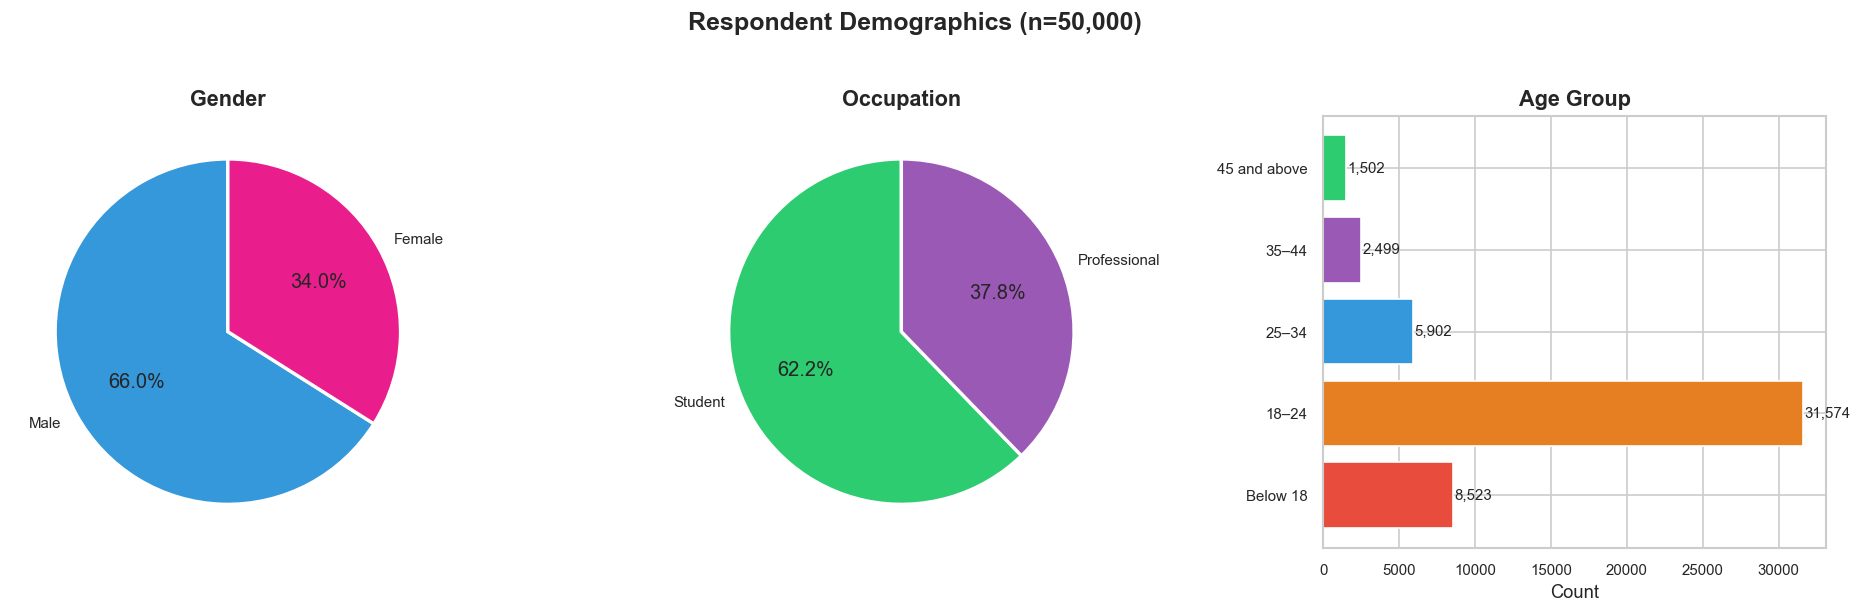

Figure 1 saved


In [7]:
# 3.1 Respondent Demographics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Respondent Demographics (n=50,000)', fontsize=15, fontweight='bold', y=1.02)

# Gender pie
gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#3498db', '#e91e8c'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Gender')

# Occupation pie
occ_counts = df['Occupation'].value_counts()
axes[1].pie(occ_counts, labels=occ_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#9b59b6'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Occupation')

# Age group horizontal bar
age_counts = df['Age Group'].value_counts().reindex(age_order)
colors_age = ['#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#2ecc71']
axes[2].barh(age_counts.index, age_counts.values, color=colors_age, edgecolor='white')
axes[2].set_title('Age Group')
axes[2].set_xlabel('Count')
for i, v in enumerate(age_counts.values):
    axes[2].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_01_demographics.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 1 saved')

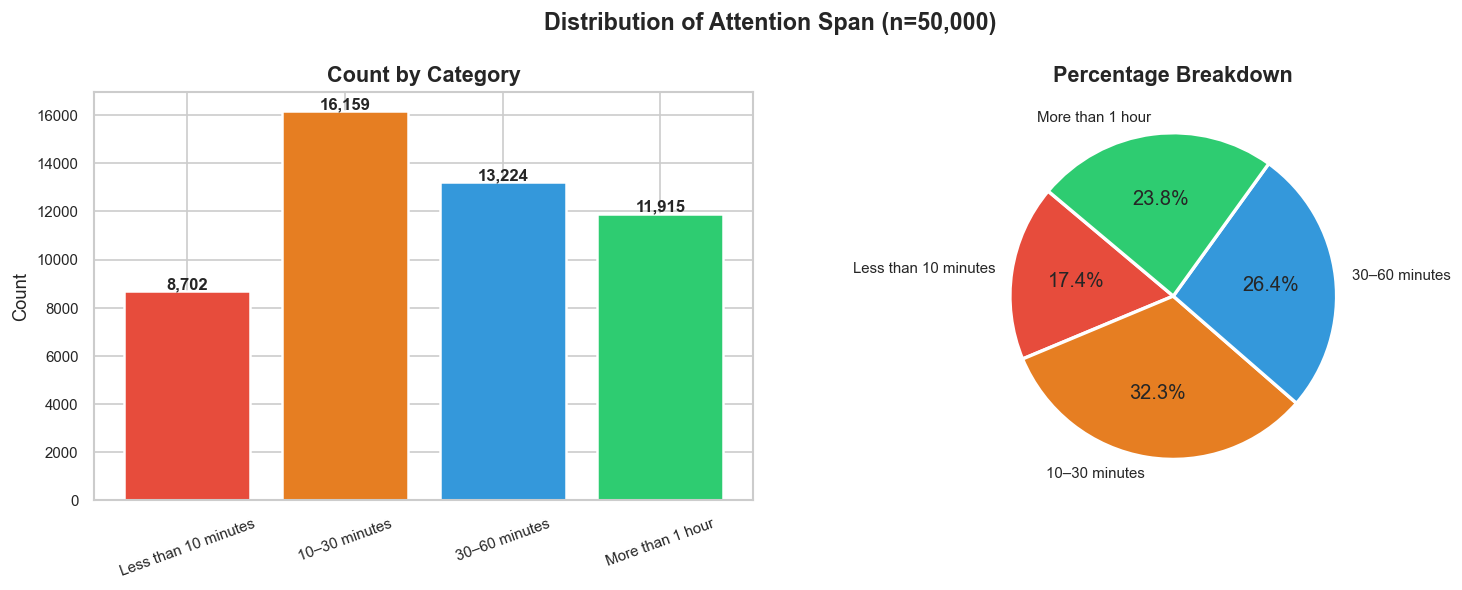

In [8]:
# 3.2 Attention Span Distribution
att_counts = df['Attention Span'].value_counts().reindex(att_order)
colors_att = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribution of Attention Span (n=50,000)', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(att_order, att_counts.values, color=colors_att, edgecolor='white', linewidth=1.5)
axes[0].set_title('Count by Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, att_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(att_counts.values, labels=att_order, autopct='%1.1f%%',
            colors=colors_att, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Percentage Breakdown')

plt.tight_layout()
plt.savefig('fig_02_attention_dist.png', bbox_inches='tight', dpi=120)
plt.show()

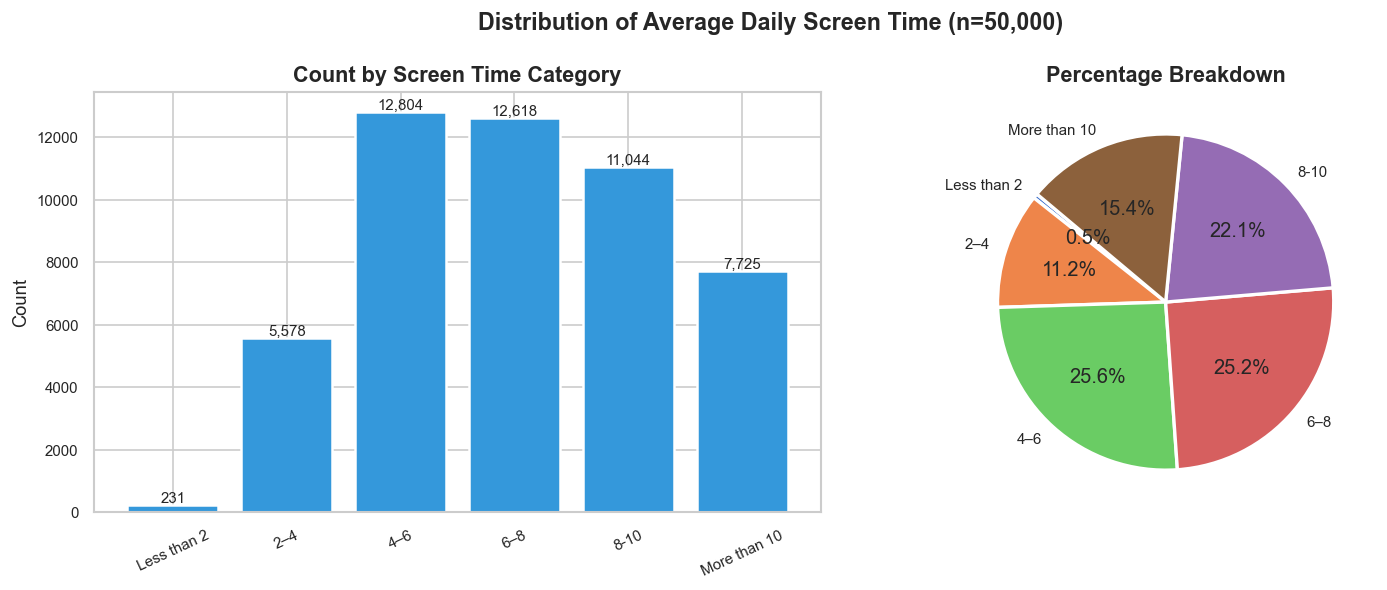

Mean numeric screen time: 7.1 hrs/day


In [9]:
# 3.3 Screen Time Distribution
st_counts = df['Average Screen Time'].value_counts().reindex(screen_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribution of Average Daily Screen Time (n=50,000)', fontsize=14, fontweight='bold')

axes[0].bar(screen_order, st_counts.values, color='#3498db', edgecolor='white', linewidth=1.5)
axes[0].set_title('Count by Screen Time Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(st_counts.values):
    axes[0].text(i, v + 80, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(st_counts.values, labels=screen_order, autopct='%1.1f%%',
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Percentage Breakdown')

plt.tight_layout()
plt.savefig('fig_03_screentime_dist.png', bbox_inches='tight', dpi=120)
plt.show()
print(f'Mean numeric screen time: {df.Screen_Hours.mean():.1f} hrs/day')

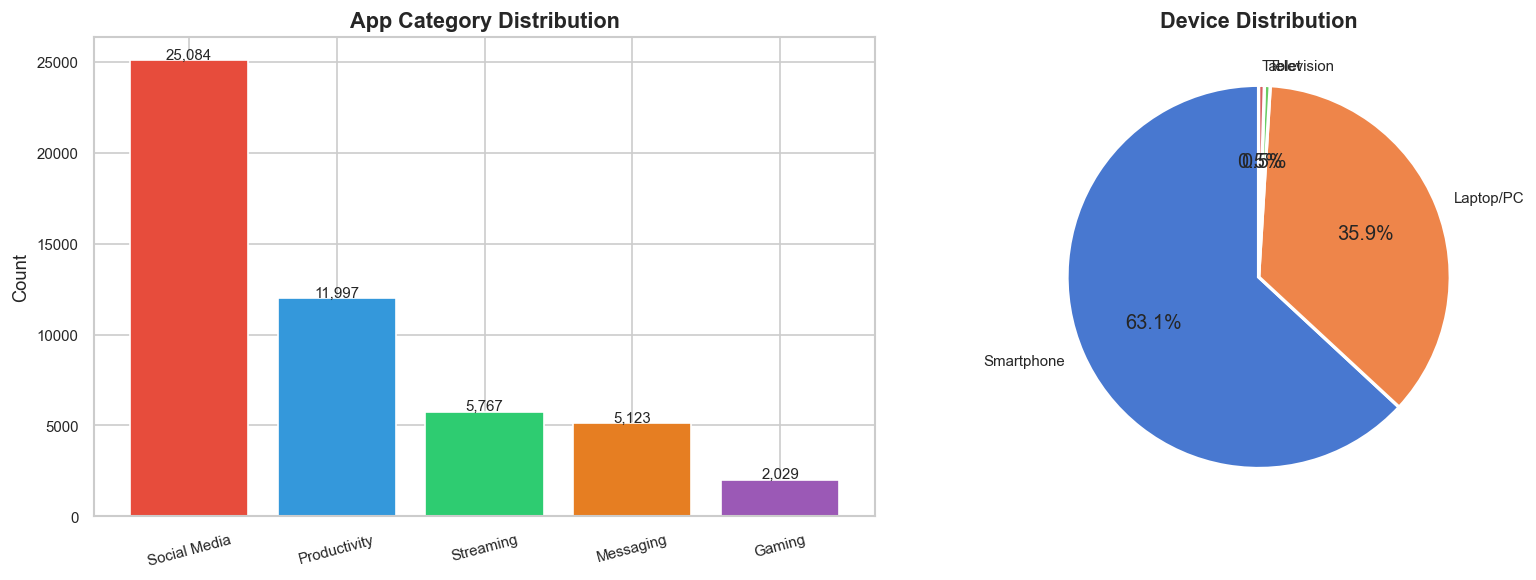

In [10]:
# 3.4 App Category & Device Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

app_counts = df['App_Category'].value_counts()
axes[0].bar(app_counts.index, app_counts.values,
            color=['#e74c3c','#3498db','#2ecc71','#e67e22','#9b59b6'],
            edgecolor='white')
axes[0].set_title('App Category Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(app_counts.values):
    axes[0].text(i, v + 80, f'{v:,}', ha='center', fontsize=9)

dev_counts = df['Device'].value_counts()
axes[1].pie(dev_counts, labels=dev_counts.index, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Device Distribution')

plt.tight_layout()
plt.savefig('fig_04_app_device_dist.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Part 4: Core Analysis — Screen Time vs Attention Span

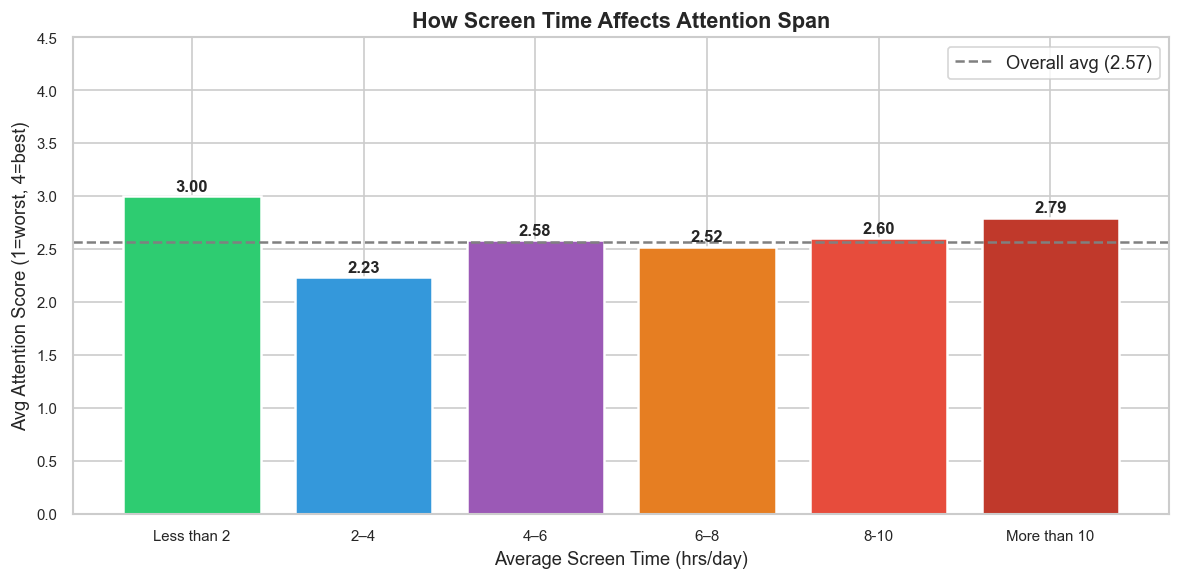

Overall average Attention Score: 2.57


In [11]:
# 4.1 Average Attention Score per Screen Time Band
avg_att = df.groupby('Average Screen Time')['Att_Score'].mean().reindex(screen_order).dropna()
overall_avg = df['Att_Score'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71','#3498db','#9b59b6','#e67e22','#e74c3c','#c0392b']
bars = ax.bar(avg_att.index, avg_att.values, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(overall_avg, color='gray', linestyle='--', linewidth=1.5,
           label=f'Overall avg ({overall_avg:.2f})')
ax.set_title('How Screen Time Affects Attention Span')
ax.set_xlabel('Average Screen Time (hrs/day)')
ax.set_ylabel('Avg Attention Score (1=worst, 4=best)')
ax.legend()
ax.set_ylim(0, 4.5)
for bar, val in zip(bars, avg_att.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_05_screentime_vs_attention.png', bbox_inches='tight', dpi=120)
plt.show()
print(f'Overall average Attention Score: {overall_avg:.2f}')

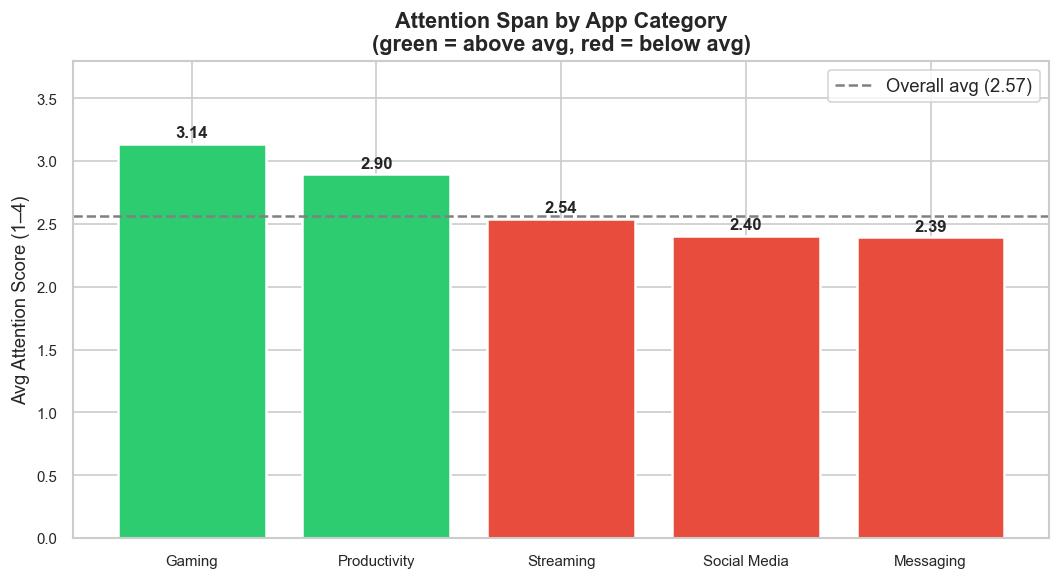

In [12]:
# 4.2 Attention Score by App Category
app_att = df.groupby('App_Category')['Att_Score'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#2ecc71' if v >= overall_avg else '#e74c3c' for v in app_att.values]
bars = ax.bar(app_att.index, app_att.values, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.axhline(overall_avg, color='gray', linestyle='--', linewidth=1.5,
           label=f'Overall avg ({overall_avg:.2f})')
ax.set_title('Attention Span by App Category\n(green = above avg, red = below avg)')
ax.set_ylabel('Avg Attention Score (1–4)')
ax.set_ylim(0, 3.8)
ax.legend()
for i, (idx, val) in enumerate(app_att.items()):
    ax.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_06_app_vs_attention.png', bbox_inches='tight', dpi=120)
plt.show()

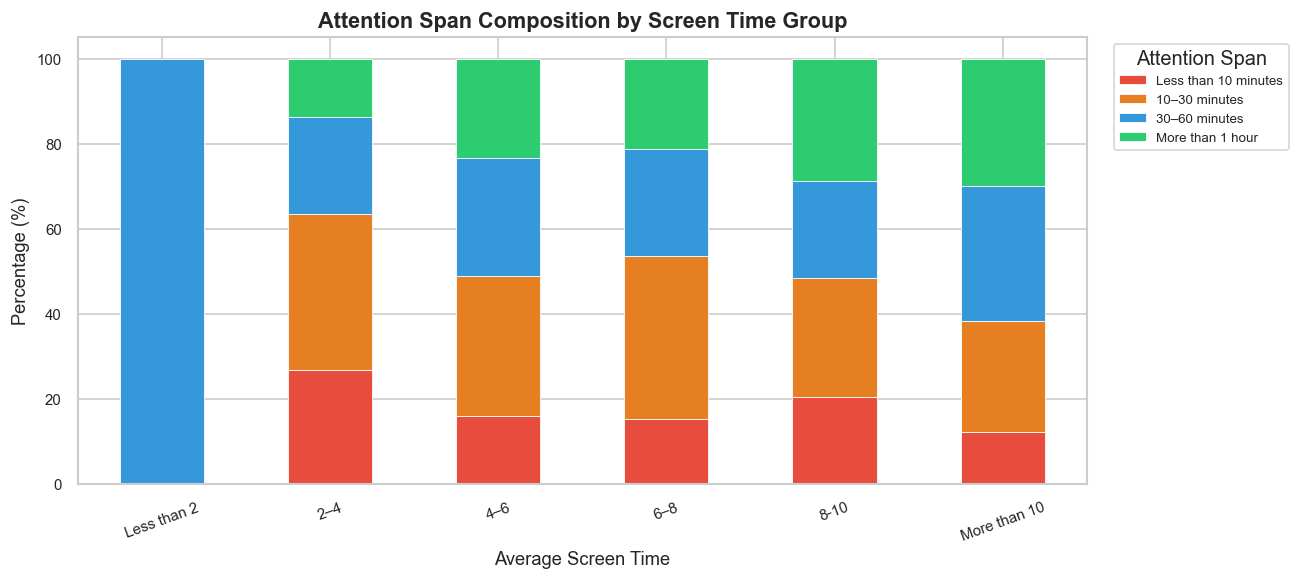

In [13]:
# 4.3 Stacked Bar: Attention Composition by Screen Time Group
stacked = pd.crosstab(df['Average Screen Time'], df['Attention Span'])
stacked = stacked.reindex(screen_order).fillna(0)[att_order]
stacked_pct = stacked.div(stacked.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
stacked_pct.plot(kind='bar', stacked=True, ax=ax,
                 color=['#e74c3c','#e67e22','#3498db','#2ecc71'],
                 edgecolor='white', linewidth=0.5)
ax.set_title('Attention Span Composition by Screen Time Group')
ax.set_xlabel('Average Screen Time')
ax.set_ylabel('Percentage (%)')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Attention Span', bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.savefig('fig_07_stacked_attention.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Part 5: Peak Distraction Analysis

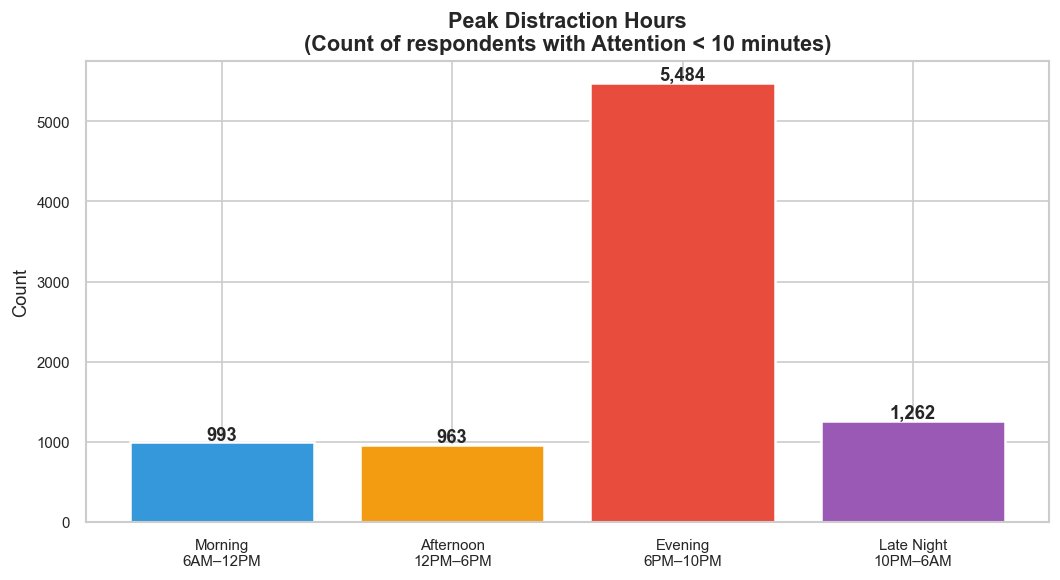

Peak period: Evening with 5,484 low-attention cases


In [14]:
# 5.1 Peak Distraction Hours (attention < 10 min)
low_att = df[df['Attention Span'] == 'Less than 10 minutes']
dist_counts = low_att['Screen Time Period'].value_counts().reindex(period_order).fillna(0)

period_labels = ['Morning\n6AM–12PM', 'Afternoon\n12PM–6PM',
                 'Evening\n6PM–10PM', 'Late Night\n10PM–6AM']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(period_labels, dist_counts.values,
              color=['#3498db','#f39c12','#e74c3c','#9b59b6'],
              edgecolor='white', linewidth=1.5)
ax.set_title('Peak Distraction Hours\n(Count of respondents with Attention < 10 minutes)')
ax.set_ylabel('Count')
for bar, val in zip(bars, dist_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(val):,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_08_peak_distraction.png', bbox_inches='tight', dpi=120)
plt.show()
print(f'Peak period: Evening with {int(dist_counts.max()):,} low-attention cases')

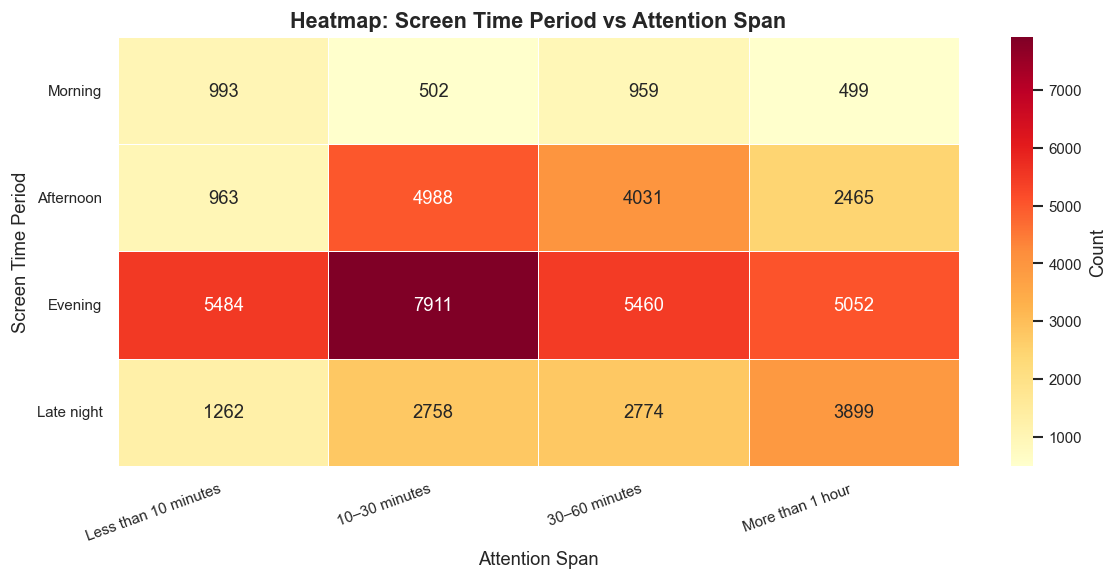

In [15]:
# 5.2 Heatmap: Screen Time Period vs Attention Span
heatmap_data = pd.crosstab(df['Screen Time Period'], df['Attention Span'])
heatmap_data = heatmap_data.reindex(period_order).fillna(0)[att_order]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Count'},
            annot_kws={'size': 11})
ax.set_title('Heatmap: Screen Time Period vs Attention Span')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
ax.set_yticklabels([p.split(' (')[0] for p in period_order], rotation=0, fontsize=9)
ax.set_ylabel('Screen Time Period')
ax.set_xlabel('Attention Span')

plt.tight_layout()
plt.savefig('fig_09_heatmap_period_attention.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Part 6: Correlation & Statistical Analysis

In [16]:
# 6.1 Encode additional columns for correlation
app_map     = {'Social Media': 1, 'Streaming': 2, 'Messaging': 3, 'Gaming': 4, 'Productivity': 5}
period_map  = {'Morning (6 AM–12 PM)': 1, 'Afternoon (12 PM–6 PM)': 2,
               'Evening (6 PM–10 PM)': 3, 'Late night (10 PM–6 AM)': 4}
notif_map   = {'Turn off notifications altogether': 1, 'Check after completing task': 2,
               'Respond to important notifications only': 3, 'Respond to all notifications': 4}
work_map    = {'Eliminate all distractions': 1, 'Take short breaks': 2,
               'Listen to music': 3, 'Work in intervals (Pomodoro)': 4}

df2 = df.copy()
df2['App_Num']    = df2['App_Category'].map(app_map)
df2['Period_Num'] = df2['Screen Time Period'].map(period_map)
df2['Gender_Num'] = df2['Gender'].map({'Female': 0, 'Male': 1})
df2['Occ_Num']    = df2['Occupation'].map({'Student': 0, 'Professional': 1})
df2['Notif_Num']  = df2['Notification Handling'].map(notif_map)
df2['Work_Num']   = df2['Work Strategy'].map(work_map)

corr_df = df2[['Screen_Hours','App_Num','Period_Num','Att_Score',
               'Prod_Score','Notif_Num','Work_Num','Gender_Num','Occ_Num']].copy()
corr_df.columns = ['Screen Hours','App Type','Time Period',
                   'Attention','Productivity','Notifications',
                   'Work Strategy','Gender','Occupation']

print('✅ Numeric encoding done')

✅ Numeric encoding done


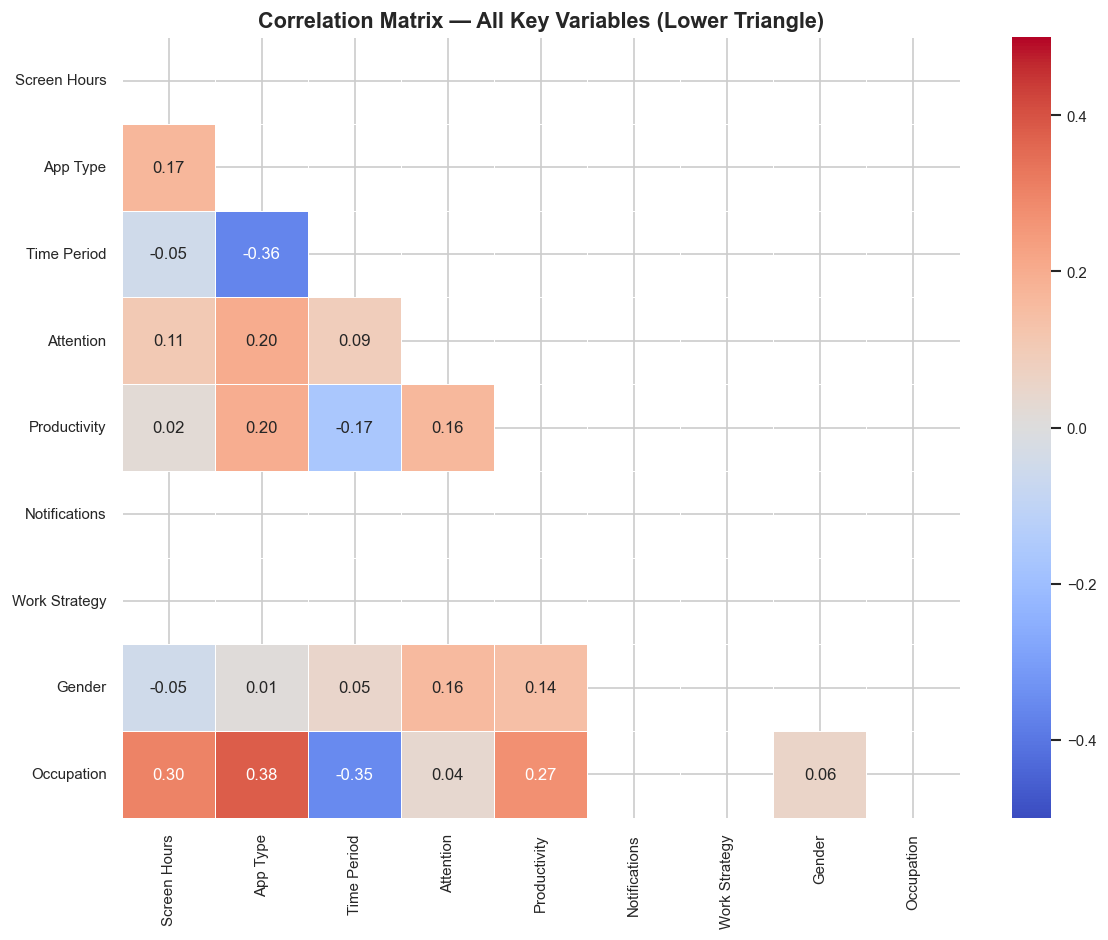

In [17]:
# 6.2 Full Correlation Heatmap
corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 10}, vmin=-0.5, vmax=0.5)
ax.set_title('Correlation Matrix — All Key Variables (Lower Triangle)')

plt.tight_layout()
plt.savefig('fig_10_correlation_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

In [18]:
# 6.3 Pearson r vs Attention Score — Statistical Tests
predictors = {
    'Screen Hours'  : 'Screen_Hours',
    'App Type'      : 'App_Num',
    'Time Period'   : 'Period_Num',
    'Productivity'  : 'Prod_Score',
    'Notifications' : 'Notif_Num',
    'Work Strategy' : 'Work_Num',
    'Gender'        : 'Gender_Num',
    'Occupation'    : 'Occ_Num'
}

print(f'{'Variable':<18} {'Pearson r':>10} {'p-value':>12} {'Significant':>12}')
print('-' * 56)
for label, col in predictors.items():
    r, p = stats.pearsonr(df2[col].dropna(), df2.loc[df2[col].notna(), 'Att_Score'])
    sig = 'YES ***' if p < 0.001 else ('YES *' if p < 0.05 else 'NO')
    print(f'{label:<18} {r:>10.3f} {p:>12.4e} {sig:>12}')

Variable            Pearson r      p-value  Significant
--------------------------------------------------------
Screen Hours            0.109  1.5578e-131      YES ***
App Type                0.202   0.0000e+00      YES ***
Time Period             0.088   6.6971e-86      YES ***
Productivity            0.165  1.7182e-300      YES ***
Notifications             nan          nan           NO
Work Strategy             nan          nan           NO
Gender                  0.157  2.0514e-272      YES ***
Occupation              0.037   1.0561e-16      YES ***


---
## Part 7: Subgroup Analysis

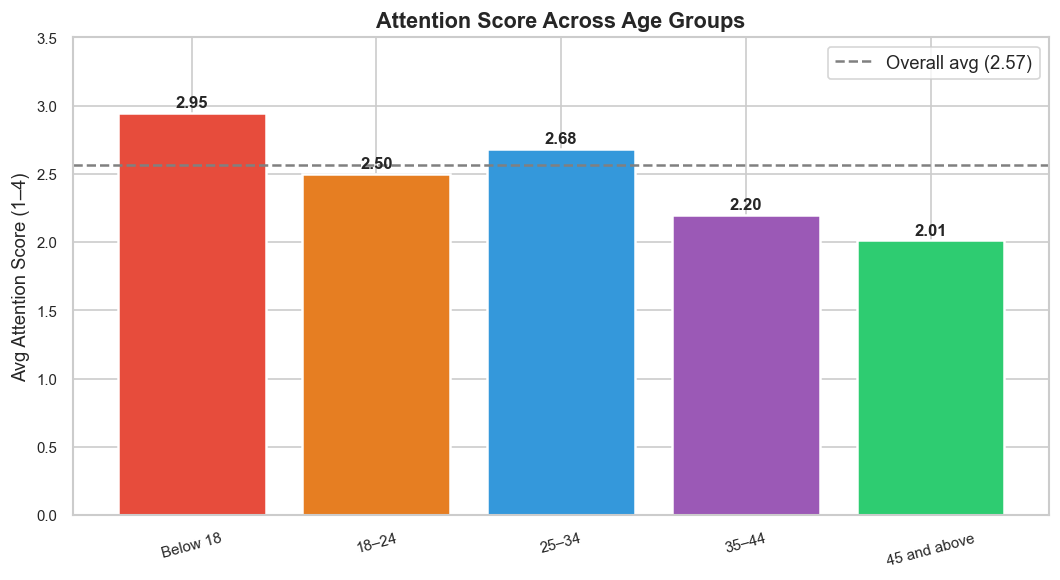

In [19]:
# 7.1 Attention Score by Age Group
age_att = df.groupby('Age Group')['Att_Score'].mean().reindex(age_order).dropna()

fig, ax = plt.subplots(figsize=(9, 5))
colors_age = ['#e74c3c','#e67e22','#3498db','#9b59b6','#2ecc71']
bars = ax.bar(age_att.index, age_att.values, color=colors_age, edgecolor='white', linewidth=1.5)
ax.axhline(overall_avg, color='gray', linestyle='--', linewidth=1.5,
           label=f'Overall avg ({overall_avg:.2f})')
ax.set_title('Attention Score Across Age Groups')
ax.set_ylabel('Avg Attention Score (1–4)')
ax.tick_params(axis='x', rotation=15)
ax.legend()
ax.set_ylim(0, 3.5)
for bar, val in zip(bars, age_att.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_11_age_attention.png', bbox_inches='tight', dpi=120)
plt.show()

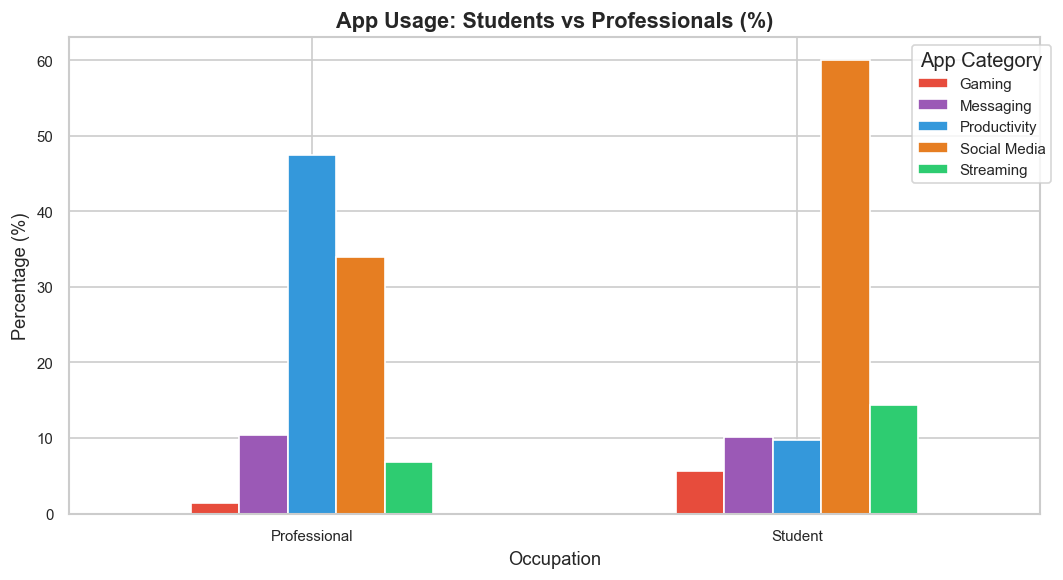

In [20]:
# 7.2 App Usage: Students vs Professionals (Stacked %)
occ_app = pd.crosstab(df['Occupation'], df['App_Category'])
occ_app_pct = occ_app.div(occ_app.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
occ_app_pct.plot(kind='bar', ax=ax, edgecolor='white',
                 color=['#e74c3c','#9b59b6','#3498db','#e67e22','#2ecc71'])
ax.set_title('App Usage: Students vs Professionals (%)')
ax.set_ylabel('Percentage (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='App Category', bbox_to_anchor=(1.02, 1), fontsize=9)

plt.tight_layout()
plt.savefig('fig_12_occupation_app.png', bbox_inches='tight', dpi=120)
plt.show()

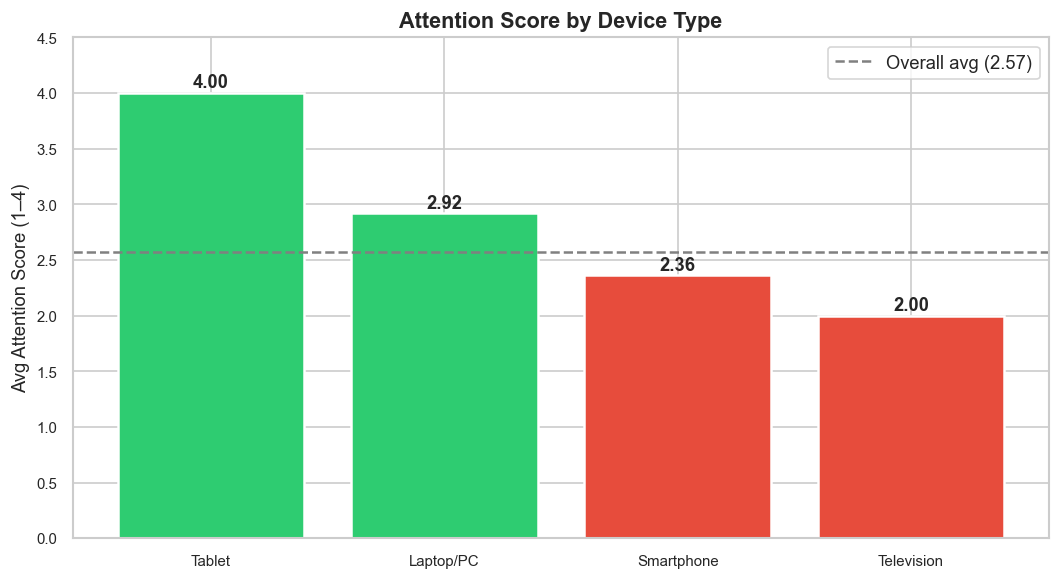

In [21]:
# 7.3 Attention Score by Device
dev_att = df.groupby('Device')['Att_Score'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(dev_att.index, dev_att.values,
              color=['#2ecc71' if v >= overall_avg else '#e74c3c' for v in dev_att.values],
              edgecolor='white', linewidth=1.5)
ax.axhline(overall_avg, color='gray', linestyle='--', linewidth=1.5,
           label=f'Overall avg ({overall_avg:.2f})')
ax.set_title('Attention Score by Device Type')
ax.set_ylabel('Avg Attention Score (1–4)')
ax.legend()
ax.set_ylim(0, 4.5)
for bar, val in zip(bars, dev_att.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_13_device_attention.png', bbox_inches='tight', dpi=120)
plt.show()

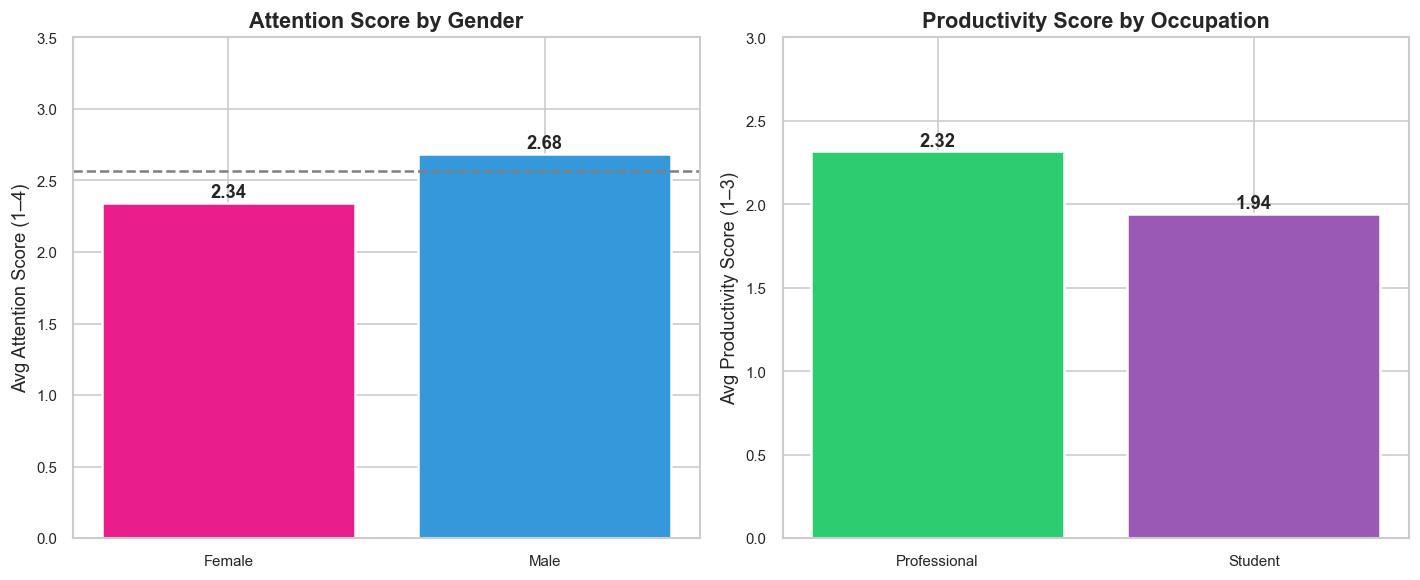

In [22]:
# 7.4 Gender vs Attention Score
gender_att = df.groupby('Gender')['Att_Score'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(gender_att.index, gender_att.values,
            color=['#e91e8c', '#3498db'], edgecolor='white', linewidth=1.5)
axes[0].axhline(overall_avg, color='gray', linestyle='--', linewidth=1.5)
axes[0].set_title('Attention Score by Gender')
axes[0].set_ylabel('Avg Attention Score (1–4)')
axes[0].set_ylim(0, 3.5)
for i, (g, v) in enumerate(gender_att.items()):
    axes[0].text(i, v + 0.04, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

# Productivity by Occupation
occ_prod = df.groupby('Occupation')['Prod_Score'].mean()
axes[1].bar(occ_prod.index, occ_prod.values,
            color=['#2ecc71', '#9b59b6'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Productivity Score by Occupation')
axes[1].set_ylabel('Avg Productivity Score (1–3)')
axes[1].set_ylim(0, 3.0)
for i, (o, v) in enumerate(occ_prod.items()):
    axes[1].text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_14_gender_occupation.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Part 8: Key Findings Summary

In [23]:
# 8.1 Print Summary Statistics Table
summary = {
    'Total Records'           : f"{len(df):,}",
    'Avg Attention Score'     : f"{df.Att_Score.mean():.2f} / 4.0",
    'Avg Screen Time'         : f"{df.Screen_Hours.mean():.1f} hrs/day",
    'Avg Productivity Score'  : f"{df.Prod_Score.mean():.2f} / 3.0",
    'Most Common Age Group'   : df['Age Group'].mode()[0],
    'Most Used App'           : df['App_Category'].mode()[0],
    'Best Attention Age'      : df.groupby('Age Group')['Att_Score'].mean().idxmax(),
    'Worst Attention Age'     : df.groupby('Age Group')['Att_Score'].mean().idxmin(),
    'Best Attention App'      : df.groupby('App_Category')['Att_Score'].mean().idxmax(),
    'Worst Attention App'     : df.groupby('App_Category')['Att_Score'].mean().idxmin(),
    'Best Attention Device'   : df.groupby('Device')['Att_Score'].mean().idxmax(),
    'Peak Distraction Period' : low_att['Screen Time Period'].value_counts().idxmax().split(' (')[0]
}

print('=' * 55)
print('        KEY FINDINGS SUMMARY')
print('=' * 55)
for k, v in summary.items():
    print(f'  {k:<28}: {v}')
print('=' * 55)

        KEY FINDINGS SUMMARY
  Total Records               : 50,000
  Avg Attention Score         : 2.57 / 4.0
  Avg Screen Time             : 7.1 hrs/day
  Avg Productivity Score      : 2.09 / 3.0
  Most Common Age Group       : 18–24
  Most Used App               : Social Media
  Best Attention Age          : Below 18
  Worst Attention Age         : 45 and above
  Best Attention App          : Gaming
  Worst Attention App         : Messaging
  Best Attention Device       : Tablet
  Peak Distraction Period     : Evening


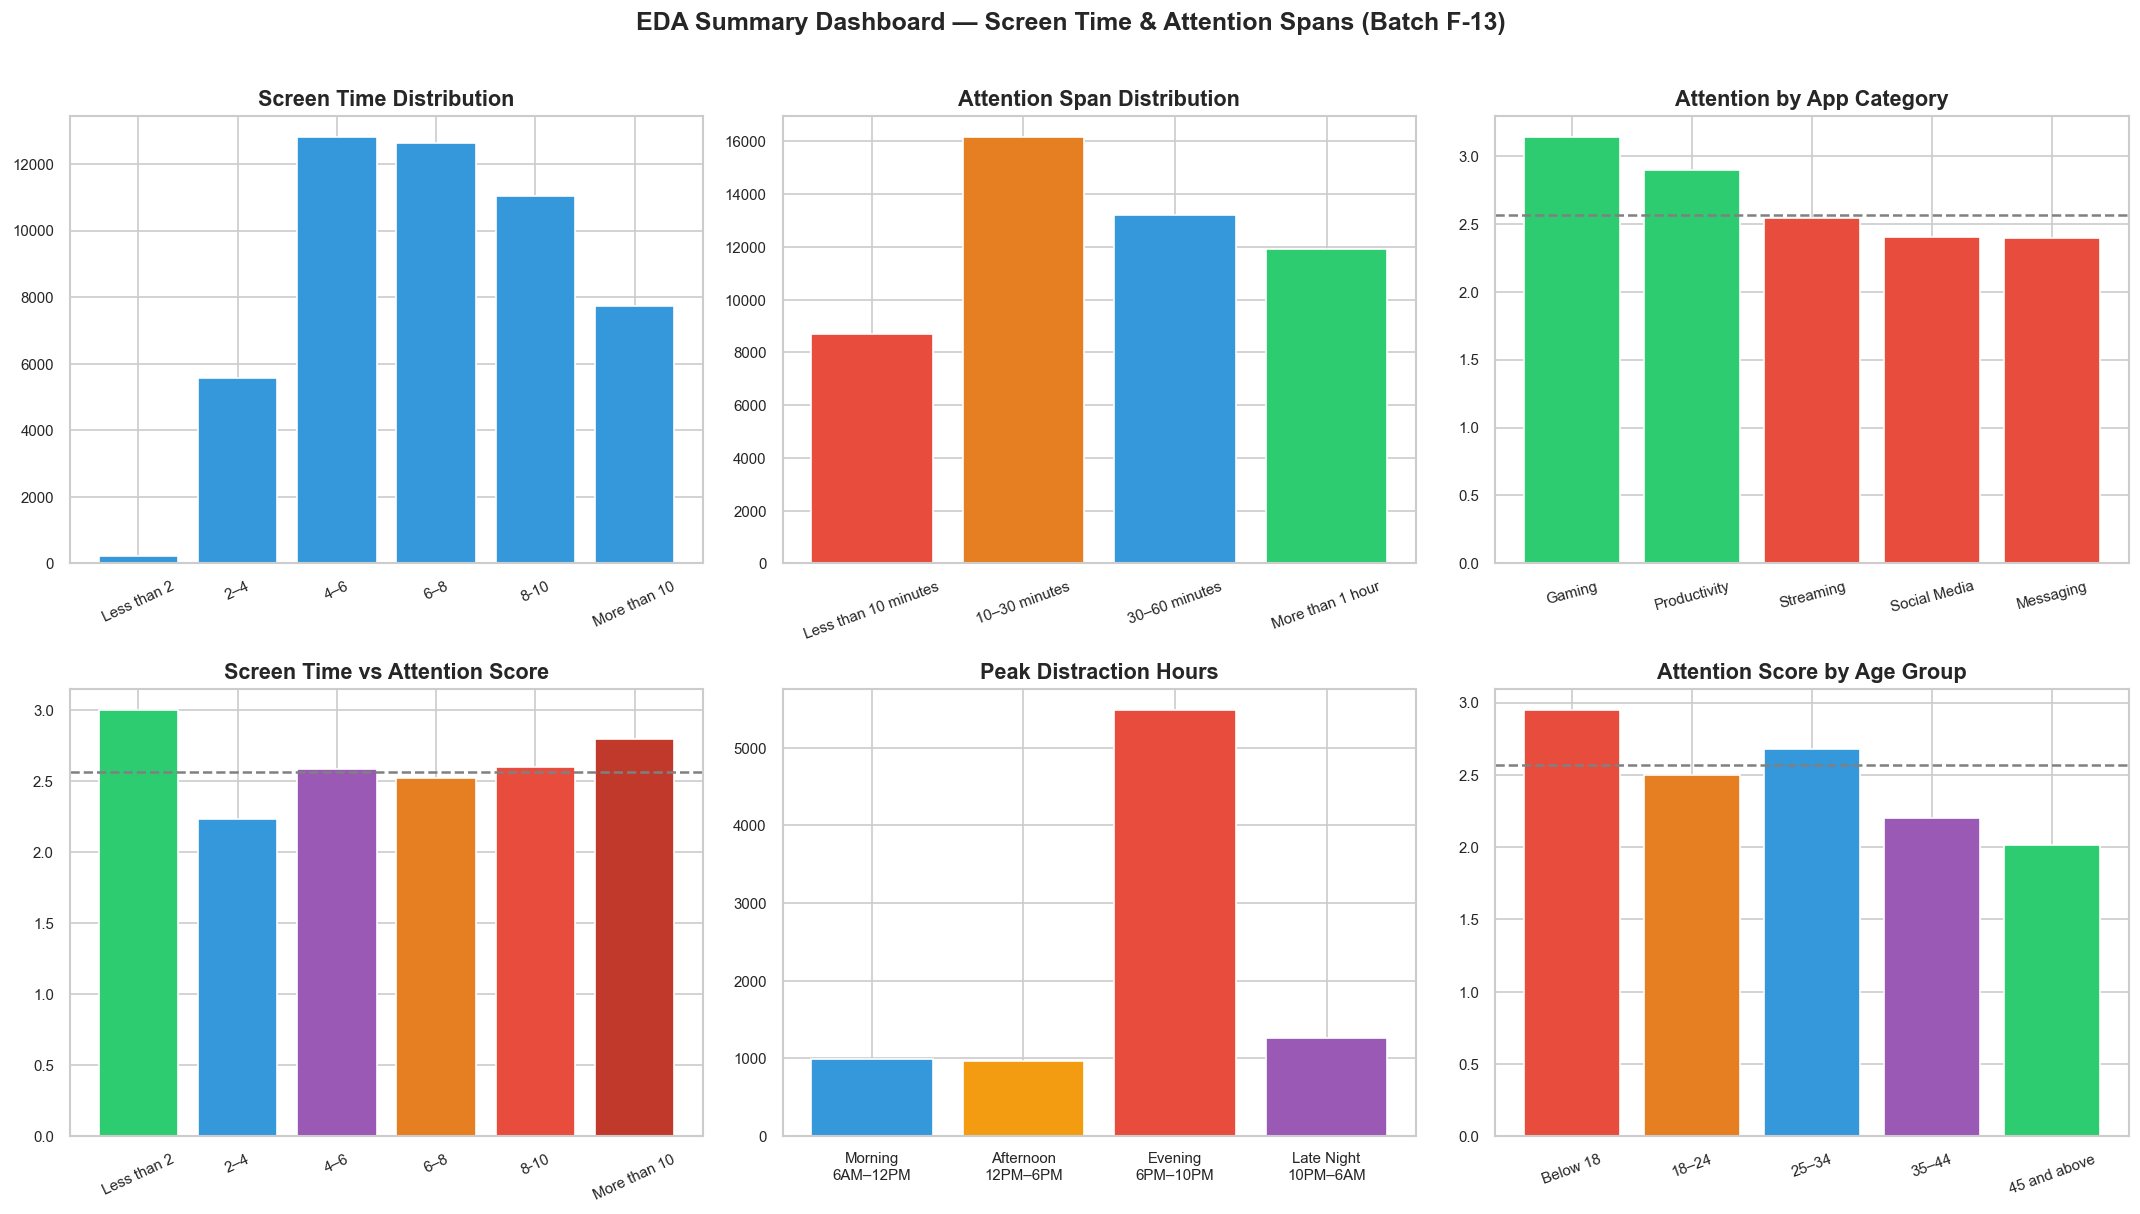

✅ All analysis complete! Figures saved.


In [24]:
# 8.2 Final Combined Dashboard Figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA Summary Dashboard — Screen Time & Attention Spans (Batch F-13)',
             fontsize=15, fontweight='bold', y=1.01)

# [0,0] Screen time dist
axes[0,0].bar(screen_order, st_counts.values, color='#3498db', edgecolor='white')
axes[0,0].set_title('Screen Time Distribution')
axes[0,0].tick_params(axis='x', rotation=25)

# [0,1] Attention dist
axes[0,1].bar(att_order, att_counts.values, color=colors_att, edgecolor='white')
axes[0,1].set_title('Attention Span Distribution')
axes[0,1].tick_params(axis='x', rotation=20)

# [0,2] App attention
bar_c = ['#2ecc71' if v >= overall_avg else '#e74c3c' for v in app_att.values]
axes[0,2].bar(app_att.index, app_att.values, color=bar_c, edgecolor='white')
axes[0,2].axhline(overall_avg, color='gray', linestyle='--')
axes[0,2].set_title('Attention by App Category')
axes[0,2].tick_params(axis='x', rotation=15)

# [1,0] Screentime vs attention
axes[1,0].bar(avg_att.index, avg_att.values, color=colors, edgecolor='white')
axes[1,0].axhline(overall_avg, color='gray', linestyle='--')
axes[1,0].set_title('Screen Time vs Attention Score')
axes[1,0].tick_params(axis='x', rotation=25)

# [1,1] Peak distraction
axes[1,1].bar(period_labels, dist_counts.values,
              color=['#3498db','#f39c12','#e74c3c','#9b59b6'], edgecolor='white')
axes[1,1].set_title('Peak Distraction Hours')

# [1,2] Age group attention
axes[1,2].bar(age_att.index, age_att.values, color=colors_age, edgecolor='white')
axes[1,2].axhline(overall_avg, color='gray', linestyle='--')
axes[1,2].set_title('Attention Score by Age Group')
axes[1,2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig_15_summary_dashboard.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ All analysis complete! Figures saved.')